# Wiskundig modelleren van de groei van de populatie nijlpaarden van Escobar

## Modelleren m.b.v. een Lesliematrix van de groei van de populatie mannetjes en de populatie vrouwtjes

In [1]:
# nodige modules importeren
import numpy as np
import matplotlib.pyplot as plt

### Gegevens

In [2]:
# nijlpaarden worden maximaal 45 jaar
leeftijden = np.arange(46)
print(leeftijden)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [3]:
# bevolkingsmatrix met aantallen per leeftijd
# begin aantal nijlpaarden te tellen vanaf het jaar 1994, dan zijn er 4 (3 vrouwtjes en 1 mannetje)
# jaar 0 is 1994 - nijlpaarden zijn dan 23 jaar oud
n0F = np.zeros(46)  # aanmaken bevolkingsmatrix vrouwtjes van 0 t.e.m. 46 jaar, ze worden max. 45 jaar
n0M = np.zeros(46)  # aanmaken bevolkingsmatrix mannetjes van 0 t.e.m. 46 jaar, ze worden max. 45 jaar
n0F[22] = 3         # invullen aantal vrouwtjes van 23 jaar
n0M[22] = 1         # invullen aantal mannetjes van 23 jaar
print(n0F)
print(n0M)
print(n0F.shape)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(46,)


In [4]:
# vruchtbaar vanaf leeftijd van 3 jaar - bij optimale vruchtbaarheid 1 kalf op 2 jaar
# cijfers uit wetenschapelijke paper
# wordt eerste rij in vierkante matrix - migratiematrix (migratie van leeftijd) - Lesliematrix 
vruchtbaarheid = np.array([[0.0, 0.0, 0.0, 0.009, 0.06, 0.25, 0.44, 0.491, 0.499, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]])

# overlevingscijfers
# bv. van de 0-jarigen wordt 88 % 1 jaar, van de 45-jarigen wordt 0 % 46 jaar
female_overleving = np.array([0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.880, 0.859, 
                  0.834, 0.806, 0.772, 0.732, 0.686, 0.0])  # -> nog naar diagonaalmatrix
male_overleving = np.array([0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969,
                 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 
                 0.817, 0.785, 0.748, 0.704, 0.653, 0.0])  # -> nog naar diagonaalmatrix

print(vruchtbaarheid)
print(female_overleving)
print(male_overleving)

print(vruchtbaarheid.shape)
print(female_overleving.shape)
print(male_overleving.shape)

[[0.    0.    0.    0.009 0.06  0.25  0.44  0.491 0.499 0.5   0.5   0.5
  0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5
  0.5   0.5   0.495 0.49  0.485 0.48  0.475 0.47  0.465 0.46  0.455 0.45
  0.445 0.44  0.435 0.43  0.425 0.42  0.415 0.41  0.405 0.4  ]]
[0.88  0.94  0.97  0.97  0.97  0.97  0.97  0.97  0.97  0.97  0.972 0.972
 0.972 0.972 0.972 0.972 0.972 0.972 0.972 0.972 0.972 0.972 0.972 0.972
 0.972 0.972 0.972 0.972 0.972 0.972 0.967 0.961 0.954 0.946 0.936 0.926
 0.913 0.897 0.88  0.859 0.834 0.806 0.772 0.732 0.686 0.   ]
[0.88  0.94  0.97  0.97  0.97  0.97  0.97  0.97  0.97  0.97  0.969 0.969
 0.969 0.969 0.969 0.969 0.969 0.969 0.969 0.969 0.969 0.969 0.969 0.969
 0.969 0.969 0.969 0.969 0.969 0.969 0.963 0.957 0.949 0.94  0.93  0.918
 0.904 0.887 0.867 0.844 0.817 0.785 0.748 0.704 0.653 0.   ]
(1, 46)
(46,)
(46,)


### Lesliematrices opstellen

In [5]:
# Lesliematrix vrouwtjes: F
F_onderstedeel = np.identity(46) * female_overleving
print(F_onderstedeel)
print(F_onderstedeel.shape)

[[0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 [0.    0.    0.97  ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(46, 46)


In [6]:
# eerste rij Lesliematrix komt overeen met de rijmatrix vvan de vruchtbaarheid
F = np.concatenate((vruchtbaarheid,F_onderstedeel))
print(F)
print(F.shape)

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(47, 46)


In [7]:
# laatste rij wegdoen
F = F[0:46,]
print(F)
print(F.shape)

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]]
(46, 46)


In [8]:
# Lesliematrix mannetjes: M
M_onderstedeel = np.identity(46) * male_overleving
print(M_onderstedeel)
print(M_onderstedeel.shape)

[[0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 [0.    0.    0.97  ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(46, 46)


In [9]:
# mannetjes baren niet, dus eerste rij van de Lesliematrix bevat enkel nullen
rij1_M = np.zeros((1, 46)) 
print(rij1_M)
print(rij1_M.shape)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(1, 46)


In [10]:
M = np.concatenate((rij1_M, M_onderstedeel))
print(M)
print(M.shape)

[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(47, 46)


In [11]:
# laatste rij wegdoen
M = M[0:46,]
print(M)
print(M.shape)

[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]]
(46, 46)


### Populatiegroei bekijken

De Lesliematrices hebben als dimensie 46 x 46. Ze kunnen vermenigvuldigd worden met een kolommatrix van dimensie 46 x 1, wat dus de dimensie van de bevolkingsmatrix moet zijn. Dit klopt voor n0F en n0M. 

In [12]:
# kolommatrix nodig, matrices transponeren
n0F = np.transpose(n0F)
n0M = np.transpose(n0M)
print(n0F)
print(n0M)
print(n0F.shape)
print(n0M.shape)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(46,)
(46,)


In [13]:
# na 1 jaar, dus in 1995
# matrixvermenigvuldiging met functie dot() die de betreffende matrices als parameters meekrijgt; dot(A, B) 
n1F = np.dot(F, n0F)
print(n1F)
print(n1F.shape)
n1M = np.dot(M, n0M)
print(n1M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n1F[0]/2  
n1F[0] = nkids
print(n1F)
n1M[0] = nkids
print(n1M)

# aantal nijlpaarden
aantal_nijlpaarden_1 = np.sum(n1F) + np.sum(n1M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden_1)

[1.5   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.916
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
(46,)
[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.969
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
[0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.916
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
[0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.969
 0.    0.    0.    0.    0

In [14]:
# na 2 jaar, dus in 1996
n2F = np.dot(F, n1F)
print(n2F)
n2M = np.dot(M, n1M)
print(n2M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n2F[0]/2  
n2F[0] = nkids
print(n2F)
n2M[0] = nkids
print(n2M)

# aantal nijlpaarden
aantal_nijlpaarden_2 = np.sum(n2F) + np.sum(n2M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden_2)

[1.458    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.       0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.938961 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.729    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.     

In [15]:
# na 3 jaar, dus in 1997
n3F = np.dot(F, n2F)
print(n2F)
n3M = np.dot(M, n2M)
print(n3M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n3F[0]/2  
n3F[0] = nkids
print(n3F)
n3M[0] = nkids
print(n3M)

# aantal nijlpaarden
aantal_nijlpaarden_3 = np.sum(n3F) + np.sum(n3M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden_3)

[0.729    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.         0.64152    0.6204     0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.90985321 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.708588   0.64152    0.6204     0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.       

In [16]:
# evolutie over 41 jaar, dus van 1994 tot 2035
# t.e.m. 2004 is 10 jaar
# aantal jaren vanaf 1994 t.e.m 2004 is 11 verschillende jaren
njaar = 41

# matrix maken met bevolkingsmatrices van de vrouwtjes kolom per kolom naast elkaar
nF = np.zeros((46, njaar+1))  # matrix aanmaken met de juiste dimensie (46x41)
nF[:,0] = n0F   # eerste kolom invullen met aantallen van jaar 1994
print(nF)
print(nF.shape)

# idem voor de mannetjes
nM = np.zeros((46, njaar+1))
nM[:,0] = n0M
print(nM)
print(nM.shape)

# matrices maken die de evolutie van de totale bevolkingsaantallen weergeeft
totF = np.zeros(njaar+1)      # rijmatrix aanmaken met de juiste dimensie  42 = njaar+1
print(totF.shape)
totM = np.zeros(njaar+1)
tot = np.zeros(njaar+1)
totF[0] = np.sum(n0F)    # aantal vrouwtjes bepalen in jaar 1994 en invullen als eerste element van totF
totM[0] = np.sum(n0M)    # aantal mannetjes bepalen in jaar 1994 en invullen als eerste element van totM
tot[0] = totF[0] + totM[0]    # eerste element van tot invullen
print(totF) 
print(totM)
print(tot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 42)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 42)
(42,)
[3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
# evolutie over 41 jaar, dus van 1994 tot 2035
# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, totF[jaar], totM[jaar], tot[jaar])

1994 4.0
1995 3.666 1.7189999999999999 5.385
1996 4.223352 2.327961 6.551313
1997 4.7254981439999995 2.880361209 7.605859353
1998 5.194972195968 3.3987695355209997 8.593741731489
1999 5.629260754430976 3.8807068251979286 9.509967579628904
2000 6.045360446342456 4.343203077091006 10.388563523433461
2001 6.4961654014895664 4.839184939991375 11.335350341480941
2002 7.024338253698269 5.411346734992403 12.43568498869067
2003 7.617247822117059 6.054375812441014 13.671623634558074
2004 8.262040922795675 6.757126751219758 15.019167674015433
2005 8.947502257109248 7.508232361231679 16.455734618340927
2006 9.666780014835865 8.299693063465208 17.96647307830107
2007 10.41696221594807 9.130650782230099 19.547612998178167
2008 11.20679556947322 10.006599590993405 21.213395160466625
2009 12.044296180563732 10.937786755525227 22.982082936088958
2010 12.938447867051972 11.93351290673247 24.871960773784444
2011 13.901287407262974 13.001927249203355 26.90321465646633
2012 14.941044439188987 14.1511402800

In [18]:
totF[41]+totM[41]

194.69706433627553

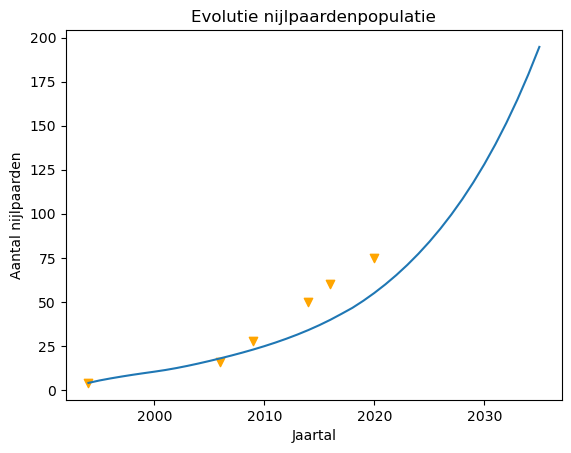

In [19]:
x = range(1994,1994+njaar+1)
jaartal = [1994, 2006, 2009, 2014, 2016, 2020]
aantal_nijlpaarden = [4, 16, 28, 50, 60, 75]

plt.title("Evolutie nijlpaardenpopulatie") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker="v", color="orange")
plt.plot(x, tot)

plt.show()

Het model is lijkt **te conservatief**. De groei van de populatie verloopt blijkbaar sneller. In 2021 werd het aantal nijlpaarden immers al op 110 geschat. 

### Aanpassingen doen aan de vruchtbaarheidscijfers

1 kalf per 1,5 jaar i.p.v. per 2 jaar. 

In [20]:
# aangepast

# vruchtbaarheid 
# worden vruchtbaar vanaf leeftijd van 2 jaar - bij optimale vruchtbaarheid 1 kalf op 1,5 jaar

# wordt eerste rij in vierkante matrix - migratiematrix (migratie van leeftijd) - Lesliematrix 
vruchtbaarheid_2 = np.array([[0.0, 0.0, 0.0, 0.009, 0.06, 0.25, 0.44, 0.491, 0.499, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]])

# overlevingscijfers
# bv. van de 0-jarigen wordt 88 % 1 jaar, van de 45-jarigen wordt 0 % 46 jaar
female_overleving_2 = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.880, 0.859, 
                  0.834, 0.806, 0.772, 0.732, 0.686, 0.0]  # -> nog naar diagonaalmatrix
male_overleving_2 = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969,
                 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 
                 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]  # -> nog naar diagonaalmatrix

print(vruchtbaarheid_2)
print(female_overleving_2)
print(male_overleving_2)

[[0.    0.    0.    0.009 0.06  0.25  0.44  0.491 0.499 0.667 0.667 0.667
  0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667
  0.667 0.667 0.495 0.49  0.485 0.48  0.475 0.47  0.465 0.46  0.455 0.45
  0.445 0.44  0.435 0.43  0.425 0.42  0.415 0.41  0.405 0.4  ]]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.88, 0.859, 0.834, 0.806, 0.772, 0.732, 0.686, 0.0]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]


In [21]:
# aangepast
F2 = np.concatenate((vruchtbaarheid_2,F_onderstedeel))
print(F2)
F2 = F2[0:46,]
print(F2)

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]]


In [22]:
# aangepast
# evolutie over 41 jaar, dus van 1994 tot 2035
njaar = 41
# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F2,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, totF[jaar], totM[jaar], tot[jaar])

1994 4.0
1995 3.9165 1.9695 5.886
1996 4.687278 2.791887 7.479165
1997 5.383647816 3.5385108809999997 8.922158697
1998 6.035690869152 4.239488208705 10.275179077857
1999 6.418710558302496 4.670156629069449 11.088867187371946
2000 6.811700431966646 5.109543062715196 11.921243494681843
2001 7.269065346087137 5.612084884588946 12.881150230676084
2002 7.8408497958232175 6.227858277117352 14.06870807294057
2003 8.51281646894805 6.949944459272003 15.462760928220053
2004 9.264356586469077 7.759442414893161 17.02379900136224
2005 10.121978091645124 8.682708195767553 18.80468628741268
2006 11.05512557751265 9.687551419293037 20.742676996805685
2007 12.056203027262063 10.768472359993087 22.824675387255148
2008 13.135773980252608 11.932821848755115 25.068595829007723
2009 14.292118087888584 13.18114828382 27.473266371708583
2010 15.540267027256315 14.529268644398476 30.06953567165479
2011 16.90303213104721 15.996090872227237 32.89912300327445
2012 18.402595447309814 17.6036286178251 36.0062240651

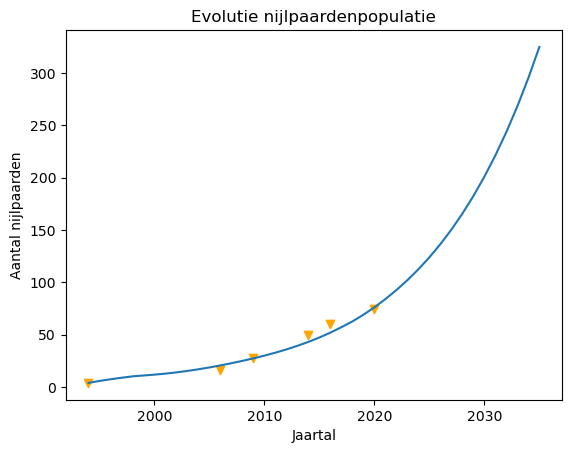

In [23]:
# aangepast
# x = range(1994,1994+njaar+1)
# jaartal_aangevuld = [1994, 2006, 2009, 2014, 2016, 2020, 2021]
# nijlpaarden_aantal_aangevuld = [4, 16, 28, 50, 60, 75, 110]

plt.title("Evolutie nijlpaardenpopulatie") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.plot(x,tot) 
plt.scatter(jaartal,aantal_nijlpaarden, marker="v", color="orange")
plt.show()

Bekijk je het jaar 2021 met 110 nijlpaarden geschat, dan is dit model nog steeds te conservatief. 

### Vruchtbaarheidscijfer nogmaals aanpassen

1 kalf per jaar? 

In [24]:
# aangepast

# vruchtbaarheid
# worden vruchtbaar vanaf leeftijd van 2 jaar - bij optimale vruchtbaarheid 1 kalf op 1,5 jaar

# wordt eerste rij in vierkante matrix - migratiematrix (migratie van leeftijd) - Lesliematrix 
vruchtbaarheid_3 = np.array([[0.0, 0.0, 0.0, 0.009, 0.06, 0.25, 0.44, 0.491, 0.499, 0.5, 0.5, 0.5, 0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]])

# overlevingscijfers
# bv. van de 0-jarigen wordt 88 % 1 jaar, van de 45-jarigen wordt 0 % 46 jaar
female_overleving_3 = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.880, 0.859, 
                  0.834, 0.806, 0.772, 0.732, 0.686, 0.0]  # -> nog naar diagonaalmatrix
male_overleving_3 = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969,
                 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 
                 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]  # -> nog naar diagonaalmatrix

print(vruchtbaarheid_3)
print(female_overleving_3)
print(male_overleving_3)

[[0.    0.    0.    0.009 0.06  0.25  0.44  0.491 0.499 0.5   0.5   0.5
  0.5   1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    0.495 0.49  0.485 0.48  0.475 0.47  0.465 0.46  0.455 0.45
  0.445 0.44  0.435 0.43  0.425 0.42  0.415 0.41  0.405 0.4  ]]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.88, 0.859, 0.834, 0.806, 0.772, 0.732, 0.686, 0.0]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]


In [25]:
# aangepast
F3 = np.concatenate((vruchtbaarheid_3,F_onderstedeel))
print(F3)
F3 = F3[0:46,]
print(F3)

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]]


In [26]:
# aangepast
# evolutie over 41 jaar, dus van 1994 tot 2035
njaar = 41
# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F3,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, totF[jaar], totM[jaar], tot[jaar])

1994 4.0
1995 4.416 2.469 6.885
1996 5.6123520000000005 3.7169610000000004 9.329313
1997 6.696006144 4.850869209 11.546875353
1998 7.712093971968 5.9158913115209995 13.627985283489
1999 7.992882921710976 6.244328992477929 14.237211914188904
2000 8.339791541025656 6.637634171774207 14.977425712799864
2001 8.810237091901454 7.153256630403263 15.963493722304717
2002 9.468983589401706 7.855992070695841 17.324975660097547
2003 10.298591076102056 8.735719066426011 19.034310142528067
2004 11.262986023614246 9.758071852038329 21.021057875652573
2005 12.296722573561627 10.857452677684057 23.154175251245682
2006 13.351737105997845 11.9831914514866 25.334928557484446
2007 14.427706701621986 13.137146065655491 27.56485276727748
2008 15.549952464396236 14.341504530773676 29.89145699516991
2009 16.968365073460454 15.848501220188181 32.81686629364864
2010 18.66725635784644 17.64416743783131 36.311423795677754
2011 20.644930147515993 19.72287208298825 40.36780223050424
2012 22.895962975281133 22.07892

Bekijk je het jaar 2021 met 110 nijlpaarden geschat, dan voldoet dit model. 

### Verder onderzoek: wat in 2070?

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 77)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 77)
(77,)
[3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
[4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

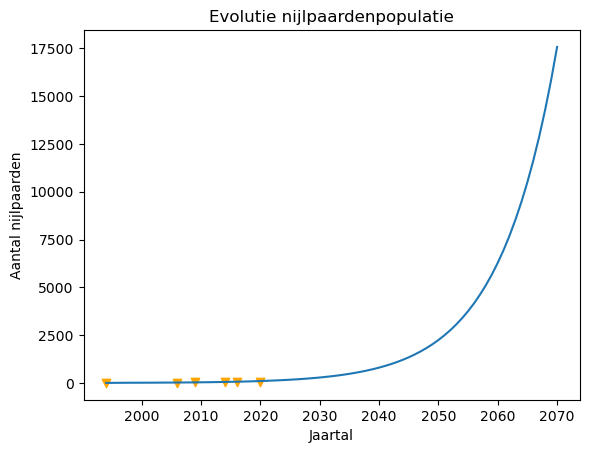

In [27]:
# wat in 2070?
# evolutie over 41+35 jaar, dus van 1994 tot 2070
njaar = 76

# matrix maken met bevolkingsmatrices van de vrouwtjes kolom per kolom naast elkaar
nF = np.zeros((46, njaar+1))  # matrix aanmaken met de juiste dimensie (46x41)
nF[:,0] = n0F   # eerste kolom invullen met aantallen van jaar 1994
print(nF)
print(nF.shape)

# idem voor de mannetjes
nM = np.zeros((46, njaar+1))
nM[:,0] = n0M
print(nM)
print(nM.shape)

# matrices maken die de evolutie van de totale bevolkingsaantallen weergeeft
totF = np.zeros(njaar+1)      # rijmatrix aanmaken met de juiste dimensie
print(np.shape(totF))
totM = np.zeros(njaar+1)
tot2 = np.zeros(njaar+1)
totF[0] = np.sum(n0F)    # aantal vrouwtjes bepalen in jaar 1994
totM[0] = np.sum(n0M)
tot2[0] = totF[0] + totM[0]
print(totF) 
print(totM)
print(tot2)


# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F3,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot2[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, tot2[jaar])

jaar = range(1994,1994+njaar+1)
#yearS = [1994, 2006, 2009, 2014, 2016, 2020, 2021]
#totS = [4, 16, 28, 50, 60, 75, 110]

plt.title("Evolutie nijlpaardenpopulatie") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.plot(jaar,tot2) 
plt.scatter(jaartal, aantal_nijlpaarden, marker="v", color="orange")
plt.show()


Antwoord:

Antwoord: Dit model voorspelt dat er in 2043 al meer dan 1000 nijlpaarden zullen zijn en in 2070 zlefs een populatie van meer dan 17000 nijlpaarden. 